In [1]:
#1) PyTorch 프레임워크 핵심 모듈 임포트
# PyTorch의 메인 엔진으로 다차원 텐서 연산과 자동 미분 기능을 수행함
import torch

# 계층(Layer), 활성화 함수, 손실 함수 등 신경망 설계의 모든 구성 요소를 포함함
from torch import nn

# 로드된 데이터를 미니 배치 단위로 묶고 셔플링하여 학습 효율을 높이는 도구임
from torch.utils.data import DataLoader

# 머신러닝 연구용 표준 데이터셋을 간편하게 내려받고 관리하는 모듈임
from torchvision import datasets

# 이미지 데이터를 PyTorch 연산에 최적화된 텐서로 변환하고 0에서 1 사이로 정규화함
from torchvision.transforms import ToTensor

In [2]:
#2) FashionMNIST 데이터셋 다운로드 및 전처리 설정
# 1. 학습(Training) 데이터셋 생성 및 설정
training_data = datasets.FashionMNIST(
    # 데이터가 저장되거나 로드될 루트 디렉토리이며 동일 경로 지정 시 중복 다운로드 방지함
    root="data",
    # 학습용 데이터 60,000개를 선택하여 인스턴스를 생성함
    train=True,
    # 로컬 경로에 데이터가 존재하지 않을 때만 온라인 서버에서 자동으로 내려받음
    download=True,
    # 이미지를 텐서로 변환하고 픽셀 값을 0에서 1 사이로 정규화하며 차원 순서를 변경함
    transform=ToTensor(),
)

# 2. 테스트(Test) 데이터셋 생성 및 설정
test_data = datasets.FashionMNIST(
    # 학습 데이터와 동일한 폴더를 참조하여 파일 중복 저장을 방지함
    root="data",
    # 테스트 전용 데이터 10,000개를 로드하여 모델 성능 평가에 활용함
    train=False,
    # 기존에 내려받은 데이터가 있다면 스킵하고 없으면 다운로드를 실행함
    download=True,
    # 학습 데이터와 동일한 전처리를 적용하여 모델 입력의 일관성을 확보함
    transform=ToTensor(),
)

In [3]:
#3) 데이터로더(DataLoader) 생성 및 텐서 형상 확인
# 한 번의 학습 단계(Iteration)에서 처리할 데이터 샘플의 개수를 정의함
batch_size = 64

# 학습용 데이터셋을 배치 단위로 묶어 모델에 전달하는 이터레이터를 생성함
train_dataloader = DataLoader(
    # 대상이 되는 학습 데이터셋 객체임
    training_data, 
    # 설정한 배치 크기만큼 데이터를 묶어서 반환함
    batch_size=batch_size
)

# 테스트용 데이터셋을 배치 단위로 로드하는 이터레이터를 생성함
test_dataloader = DataLoader(
    # 대상이 되는 테스트 데이터셋 객체임
    test_data, 
    # 모델 성능 평가 시에도 동일한 배치 크기를 적용하여 일관성을 유지함
    batch_size=batch_size
)

# 로드된 데이터의 차원과 타입을 확인하기 위해 첫 번째 배치를 순회함
for X, y in test_dataloader:
    # 이미지 데이터(X)의 형상을 출력하며 [배치 크기, 채널, 높이, 너비] 순서임
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    # 정답 라벨(y)의 형상과 데이터 타입을 출력함
    print(f"Shape of y: {y.shape} {y.dtype}")
    # 첫 번째 배치의 형상만 확인한 후 반복문을 즉시 중단함
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [4]:
#4) 연산 장치 설정 및 신경망 모델 정의
# 현재 환경에서 사용 가능한 최적의 가속 장치(GPU)를 선택함
device = (
    # NVIDIA GPU가 사용 가능한 경우 CUDA를 우선 선택함
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    # Apple Silicon 환경인 경우 MPS(Metal Performance Shaders)를 선택함
    if torch.backends.mps.is_available()
    else "cpu"
    # 위 조건이 모두 해당되지 않으면 기본 CPU를 사용함
)

# 선택된 연산 장치 종류를 콘솔에 출력함
print(f"Using {device} device")

# nn.Module을 상속받아 사용자 정의 신경망 클래스를 정의함
class NeuralNetwork(nn.Module):
    def __init__(self):
        # 부모 클래스인 nn.Module의 생성자를 호출하여 초기화함
        super().__init__()
        
        # 2차원 또는 3차원 이미지를 1차원 평탄화된 벡터로 변환하는 계층임
        # (28x28 이미지를 784개의 원소를 가진 1차원 배열로 바꿈)
        self.flatten = nn.Flatten()
        
        # 순차적으로 실행될 계층들을 묶어주는 컨테이너임
        self.linear_relu_stack = nn.Sequential(
            # 첫 번째 선형 계층으로 784개의 입력을 받아 512개의 특징으로 확장함
            nn.Linear(28*28, 512),
            # 비선형성을 부여하여 복잡한 패턴 학습을 돕는 활성화 함수임
            nn.ReLU(),
            # 두 번째 선형 계층으로 512개의 특징 간의 관계를 한 번 더 학습함
            nn.Linear(512, 512),
            # 은닉층 사이의 비선형 관계를 유지함
            nn.ReLU(),
            # 최종 출력층으로 512개의 특징을 10개의 클래스(의류 종류) 점수로 변환함
            nn.Linear(512, 10)
        )

    # 데이터가 모델을 통과하는 순전파(Forward propagation) 과정을 정의함
    def forward(self, x):
        # 입력 데이터를 1차원 벡터로 평탄화함
        x = self.flatten(x)
        # 정의된 선형 계층과 활성화 함수의 묶음을 통과시켜 결과값(Logits)을 산출함
        logits = self.linear_relu_stack(x)
        # 가공되지 않은 예측 점수인 로짓을 반환함
        return logits

# 모델 인스턴스를 생성하고 위에서 선택한 장치(CPU/GPU)의 메모리로 이동시킴
model = NeuralNetwork().to(device)

# 모델의 전체 구조와 계층별 파라미터 구성을 출력함
print(model)


Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [5]:
#5) 손실 함수 및 최적화 알고리즘 설정
# 모델의 출력값과 실제 정답 사이의 거리를 측정하는 손실 함수를 정의함
# Softmax 연산과 Negative Log Likelihood Loss를 결합하여 클래스 분류에 최적화된 형태임
loss_fn = nn.CrossEntropyLoss()

# 모델의 파라미터를 최적화하여 손실을 줄여나가는 알고리즘을 선택함
optimizer = torch.optim.SGD(
    # 모델 내부의 학습 가능한 가중치(Weights)와 편향(Bias)들을 최적화 대상으로 전달함
    model.parameters(), 
    # 학습률을 설정하며 한 번의 업데이트에서 가중치를 얼마나 크게 변경할지 결정함
    lr=1e-3
)

In [6]:
#6) 모델 학습을 위한 Train 함수 정의
def train(dataloader, model, loss_fn, optimizer):
    # 전체 데이터셋의 크기를 가져와 학습 진행률 계산에 활용함
    size = len(dataloader.dataset)
    
    # 데이터로더로부터 배치 단위로 데이터(X)와 정답(y)을 인덱스와 함께 불러옴
    for batch, (X, y) in enumerate(dataloader):
        # 입력 데이터와 정답을 모델이 위치한 연산 장치(CPU/GPU)로 전송함
        X, y = X.to(device), y.to(device)

        # 1. 예측 오류 계산 (순전파)
        # 모델에 데이터를 입력하여 예측값(logits)을 산출함
        pred = model(X)
        # 예측값과 실제 정답을 비교하여 손실(Loss)을 계산함
        loss = loss_fn(pred, y)

        # 2. 역전파 (Backpropagation)
        # 손실 함수를 미분하여 각 파라미터에 대한 기울기(Gradient)를 계산함
        loss.backward()
        # 계산된 기울기를 바탕으로 모델의 파라미터를 업데이트함
        optimizer.step()
        # 다음 배치의 기울기 계산에 영향을 주지 않도록 기존 기울기를 0으로 초기화함
        optimizer.zero_grad()

        # 100 배치마다 학습 상태(손실값 및 진행률)를 출력함
        if batch % 100 == 0:
            # 텐서 형태의 손실값에서 숫자 데이터만 추출함
            loss, current = loss.item(), (batch + 1) * len(X)
            # 현재 배치에서의 손실값과 전체 데이터 대비 진행 상황을 화면에 표시함
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    return loss

In [7]:
#7) 모델 성능 평가를 위한 Test 함수 정의
def test(dataloader, model, loss_fn):
    # 전체 테스트 데이터셋의 샘플 개수를 가져옴
    size = len(dataloader.dataset)
    # 전체 데이터셋을 배치 크기로 나눈 총 배치 수를 계산함
    num_batches = len(dataloader)
    
    # 모델을 평가 모드로 전환함
    # 드롭아웃(Dropout)이나 배치 정규화(Batch Normalization) 같은 기능을 평가용으로 고정함
    model.eval()
    
    # 총 손실값과 맞은 개수를 저장할 변수를 초기화함
    test_loss, correct = 0, 0

    # 기울기 계산을 비활성화하여 메모리 사용량을 줄이고 연산 속도를 높임
    # 평가 단계에서는 파라미터 업데이트가 필요 없으므로 필수적인 과정임
    with torch.no_grad():
        for X, y in dataloader:
            # 입력 데이터와 정답을 연산 장치(CPU/GPU)로 보냄
            X, y = X.to(device), y.to(device)
            
            # 모델을 통해 예측값(Logits)을 도출함
            pred = model(X)
            
            # 배치별 손실값을 계산하여 누적함
            test_loss += loss_fn(pred, y).item()
            
            # 예측값 중 가장 높은 확률을 가진 인덱스와 실제 정답이 일치하는지 확인하여 합산함
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    # 전체 배치 수로 나누어 평균 손실을 계산함
    test_loss /= num_batches
    # 전체 데이터 개수로 나누어 최종 정확도(Accuracy)를 산출함
    correct /= size
    
    # 최종적인 정확도와 평균 손실값을 화면에 출력함
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return test_loss, correct

In [8]:
#8) 전체 학습 및 테스트 루프 실행
# 전체 데이터셋을 반복하여 학습할 총 횟수를 정의함
epochs = 30

# 학습 과정의 수치 변화를 저장하기 위한 리스트 초기화
train_losses = []
test_losses = []
test_accs = []

# 설정한 에폭 수만큼 반복문을 실행함
for t in range(epochs):
    # 현재 진행 중인 에폭 번호를 출력하여 시각적으로 상태를 표시함
    print(f"Epoch {t+1}\n-------------------------------")
    
    # 앞서 정의한 train 함수를 호출하여 모델의 가중치를 업데이트함
    # 가중치 갱신(Backpropagation)이 일어나는 핵심 단계임
    # 각 에폭의 마지막 배치 손실을 기록
    current_train_loss=train(train_dataloader, model, loss_fn, optimizer)
    # 텐서 객체이므로 숫자로 변환하여 리스트에 추가
    train_losses.append(current_train_loss.item())
    
    # 각 에폭이 끝날 때마다 테스트 데이터를 통해 모델의 일반화 성능을 확인함
    # 학습 데이터가 아닌 데이터에 대한 오차와 정확도를 산출함
    # 평균 손실과 정확도를 반환받아 기록
    current_test_loss, current_test_acc =test(test_dataloader, model, loss_fn)
    test_losses.append(current_test_loss)
    test_accs.append(current_test_acc)

# 모든 에폭이 완료되어 전체 학습 과정이 종료되었음을 알림
print("Done!")

Epoch 1
-------------------------------
loss: 2.309655  [   64/60000]
loss: 2.302825  [ 6464/60000]
loss: 2.288506  [12864/60000]
loss: 2.273130  [19264/60000]
loss: 2.259987  [25664/60000]
loss: 2.236086  [32064/60000]
loss: 2.230297  [38464/60000]
loss: 2.204487  [44864/60000]
loss: 2.202815  [51264/60000]
loss: 2.171628  [57664/60000]
Test Error: 
 Accuracy: 49.0%, Avg loss: 2.167581 

Epoch 2
-------------------------------
loss: 2.178145  [   64/60000]
loss: 2.173885  [ 6464/60000]
loss: 2.121293  [12864/60000]
loss: 2.123688  [19264/60000]
loss: 2.085289  [25664/60000]
loss: 2.028969  [32064/60000]
loss: 2.044651  [38464/60000]
loss: 1.978002  [44864/60000]
loss: 1.982444  [51264/60000]
loss: 1.907040  [57664/60000]
Test Error: 
 Accuracy: 56.2%, Avg loss: 1.910826 

Epoch 3
-------------------------------
loss: 1.944690  [   64/60000]
loss: 1.922342  [ 6464/60000]
loss: 1.809255  [12864/60000]
loss: 1.831493  [19264/60000]
loss: 1.737002  [25664/60000]
loss: 1.687865  [32064/600

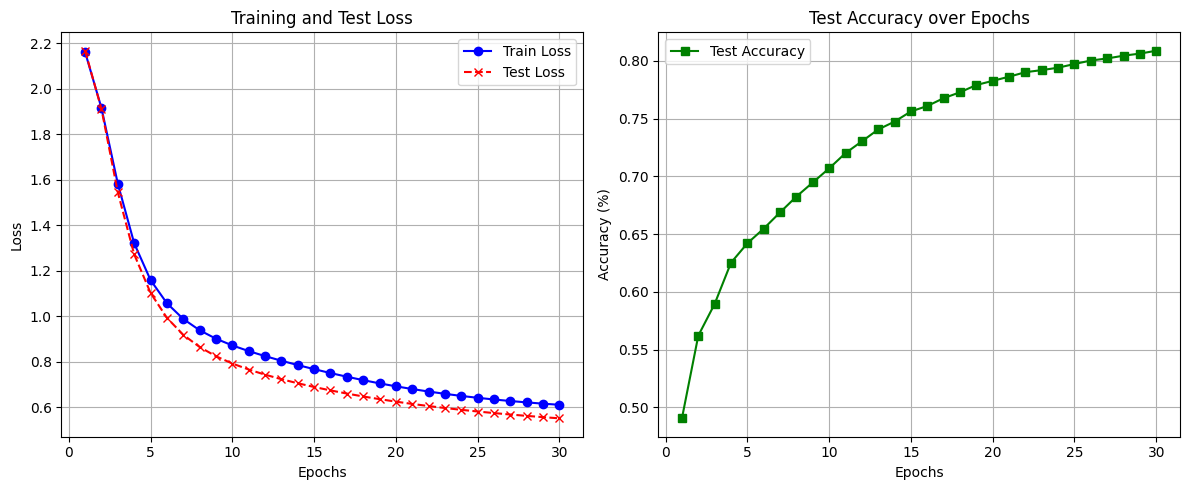

In [9]:
#9) 학습 결과 시각화
import numpy as np
import matplotlib.pyplot as plt

# 시각화를 위한 전체 레이아웃 설정 (1행 2열)
plt.figure(figsize=(12, 5))

# 1. 손실(Loss) 곡선 시각화
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', color='red', linestyle='--', marker='x')
plt.title('Training and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. 정확도(Accuracy) 곡선 시각화
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), test_accs, label='Test Accuracy', color='green', marker='s')
plt.title('Test Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

In [10]:
#10) 모델 저장 및 불러오기
# 모델의 학습 가능한 매개변수(가중치와 편향)를 딕셔너리 형태로 추출하여 파일로 저장함
# 전체 모델 객체를 저장하는 것보다 가중치(state_dict)만 저장하는 것이 이식성과 효율성 면에서 권장됨
torch.save(model.state_dict(), "model.pth")

# 모델 상태 저장 완료 메시지를 콘솔에 출력함
print("Saved PyTorch Model State to model.pth")

# 저장된 가중치를 적용하기 위해 원본과 동일한 구조의 신경망 객체를 새로 생성함
# 생성된 인스턴스를 현재 사용 가능한 연산 장치(CPU/GPU)에 할당함
model = NeuralNetwork().to(device)

# 파일로부터 불러온 가중치 딕셔너리를 새로 생성한 모델 객체에 덮어씌움
# 이때 모델의 레이어 구조와 저장된 파일의 파라미터 구조가 반드시 일치해야 함
model.load_state_dict(torch.load("model.pth"))

Saved PyTorch Model State to model.pth


<All keys matched successfully>

Predicted: "Ankle boot", Actual: "Ankle boot"


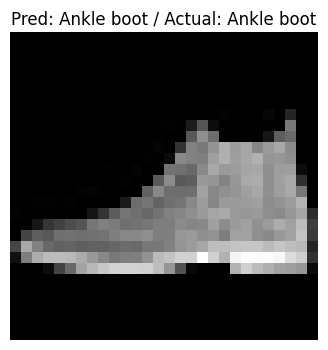

In [11]:
#11) 학습된 모델을 이용한 샘플 데이터 추론
# 모델이 분류할 10개의 의류 카테고리 명칭을 리스트로 정의함
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# 모델을 평가(Inference) 모드로 전환함
# 드롭아웃 등의 학습용 기능을 비활성화하여 일관된 예측 결과를 보장함
model.eval()

# 테스트 데이터셋의 첫 번째 샘플에서 이미지(x)와 정답 라벨(y)을 가져옴
x, y = test_data[0][0], test_data[0][1]

# 추론 과정에서는 가중치를 업데이트하지 않으므로 기울기 계산을 비활성화함
with torch.no_grad():
    # 데이터를 모델이 위치한 연산 장치(CPU/GPU)로 전송함
    #x = x.to(device)
    x = x.unsqueeze(0).to(device)
    
    # 모델에 이미지 데이터를 입력하여 클래스별 예측 점수(Logits)를 얻음
    pred = model(x)
    
    # 예측 점수 중 가장 높은 값의 인덱스를 클래스명으로 변환하고 실제 정답 명칭도 확인함
    # pred[0]은 배치 차원의 첫 번째 샘플을 의미하며 argmax(0)은 해당 텐서의 최댓값 위치를 반환함
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    
    # 모델의 예측 결과와 실제 정답을 비교하여 출력함
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

    # 이미지 시각화 
    plt.figure(figsize=(4, 4))
    # PyTorch 텐서 [C, H, W] 형식을 Matplotlib용 [H, W, C] 또는 [H, W]로 변환
    # FashionMNIST는 흑백이므로 squeeze()로 채널 차원을 제거합니다.
    plt.imshow(x.cpu().squeeze(), cmap="gray")
    plt.title(f"Pred: {predicted} / Actual: {actual}")
    plt.axis("off") # 축 정보 숨기기
    plt.show()
    